# 9. Метод опроных векторов.

Упражнения из **9 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 4.



In [149]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split
from ISLP import load_data, confusion_table
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import PolynomialFeatures

In [150]:
roc_curve = RocCurveDisplay.from_estimator

In [151]:
rng = np.random.default_rng(1)
X = rng.standard_normal((200, 2))
X[:100] += 2
X[100:150] -= 2
y = np.array([1]*150 + [2]*50)

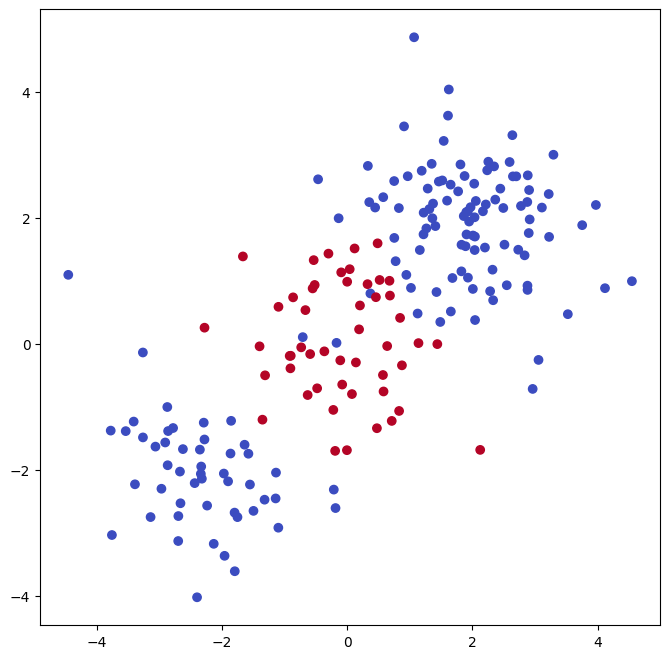

In [152]:
fig, ax = subplots(figsize = (8, 8))
ax.scatter(X[:, 0], X[:, 1], c = y, cmap= cm.coolwarm);

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [154]:
svm_linear = SVC(C = 10, kernel = 'linear')

kfold = skm.KFold(5, random_state=0, shuffle = True)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

grid = skm.GridSearchCV(svm_linear, param_grid, refit = True, cv = kfold, scoring = 'accuracy')

In [155]:
grid.fit(X_train, y_train)
grid.best_params_
best_lin = grid.best_estimator_

In [156]:
grid.cv_results_[('mean_test_score')]

array([0.74285714, 0.74285714, 0.74285714, 0.74285714, 0.74285714,
       0.74285714, 0.74285714])

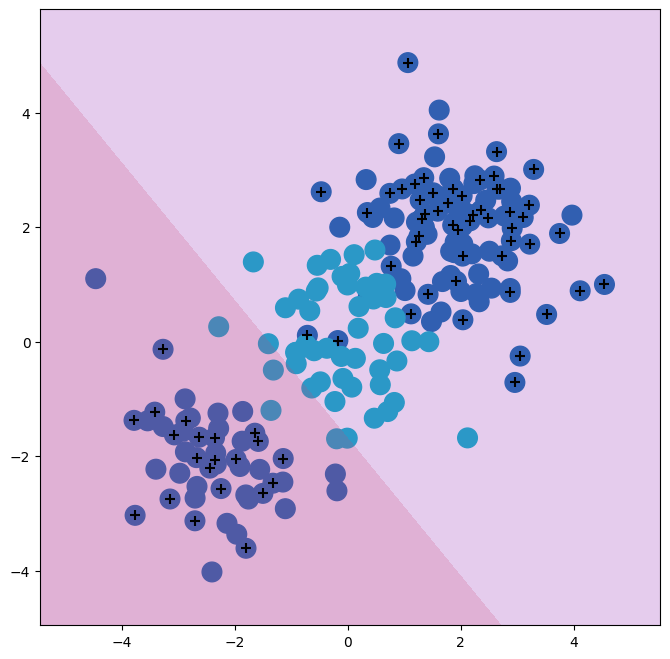

In [157]:
fig, ax = subplots(figsize = (8, 8))
plot_svm(X, y, best_lin, ax = ax)

In [158]:
y_test_hat = best_lin.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,1,2
Predicted,,
1,46,14
2,0,0


In [159]:
print(classification_report(y_test, y_test_hat));

              precision    recall  f1-score   support

           1       0.77      1.00      0.87        46
           2       0.00      0.00      0.00        14

    accuracy                           0.77        60
   macro avg       0.38      0.50      0.43        60
weighted avg       0.59      0.77      0.67        60



C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [160]:
svm_poly = SVC(C = 10, kernel = 'poly', degree = 3)

kfold = skm.KFold(5, random_state=0, shuffle = True)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100], 'degree': [2, 3, 4, 5, 6]}

grid = skm.GridSearchCV(svm_poly, param_grid, refit = True, cv = kfold, scoring = 'accuracy')

In [161]:
grid.fit(X_train, y_train)
best_poly = grid.best_estimator_

In [162]:
grid.best_params_

{'C': 1, 'degree': 2}

In [163]:
grid.cv_results_[('mean_test_score')]

array([0.74285714, 0.74285714, 0.74285714, 0.74285714, 0.74285714,
       0.74285714, 0.74285714, 0.74285714, 0.74285714, 0.74285714,
       0.85714286, 0.74285714, 0.8       , 0.74285714, 0.74285714,
       0.93571429, 0.74285714, 0.93571429, 0.74285714, 0.88571429,
       0.93571429, 0.74285714, 0.93571429, 0.74285714, 0.93571429,
       0.92857143, 0.74285714, 0.92857143, 0.74285714, 0.92857143,
       0.92857143, 0.74285714, 0.92857143, 0.74285714, 0.91428571])

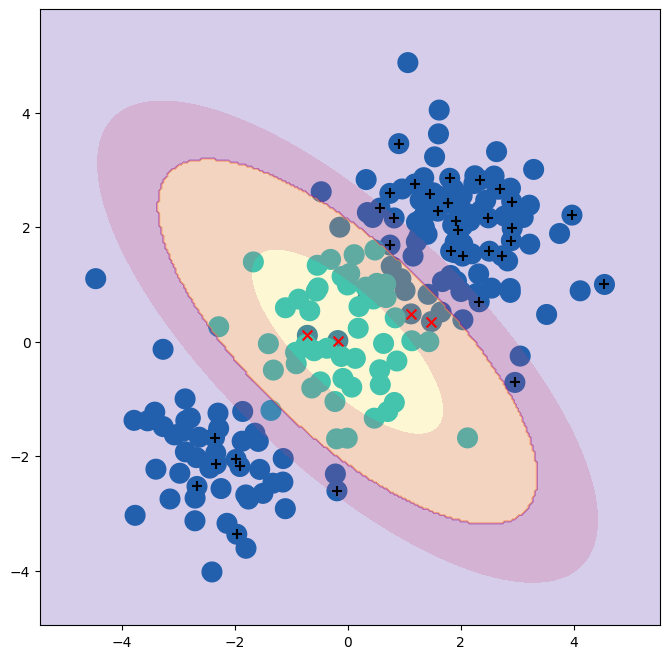

In [164]:
fig, ax = subplots(figsize = (8, 8))
plot_svm(X, y, best_poly, ax = ax)

In [165]:
y_test_hat = best_poly.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,1,2
Predicted,,
1,42,0
2,4,14


In [166]:
print(classification_report(y_test, y_test_hat));

              precision    recall  f1-score   support

           1       1.00      0.91      0.95        46
           2       0.78      1.00      0.88        14

    accuracy                           0.93        60
   macro avg       0.89      0.96      0.91        60
weighted avg       0.95      0.93      0.94        60



In [167]:
svm_rbf = SVC(C = 10, kernel = 'rbf')

kfold = skm.KFold(5, random_state=0, shuffle = True)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

grid = skm.GridSearchCV(svm_rbf, param_grid, refit = True, cv = kfold, scoring = 'accuracy')

In [168]:
grid.fit(X_train, y_train)
best_rbf = grid.best_estimator_

In [169]:
grid.best_params_

{'C': 5}

In [170]:
grid.cv_results_[('mean_test_score')]

array([0.74285714, 0.74285714, 0.75714286, 0.93571429, 0.94285714,
       0.93571429, 0.94285714])

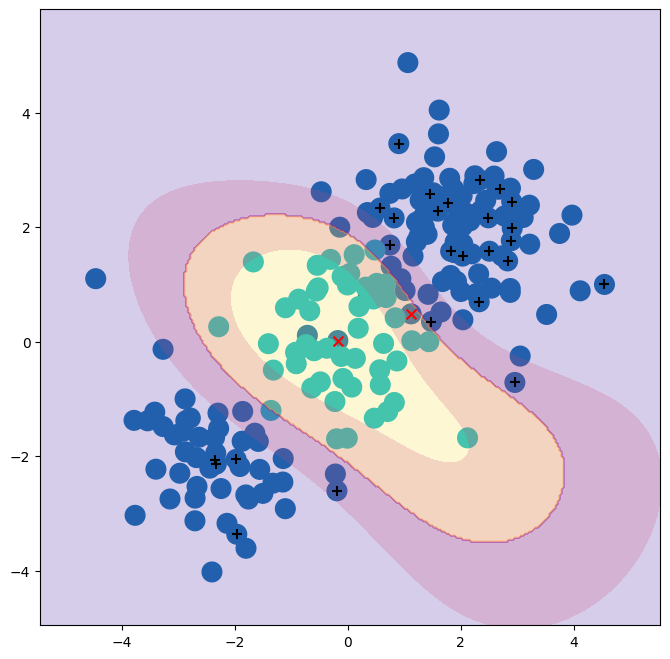

In [171]:
fig, ax = subplots(figsize = (8, 8))
plot_svm(X, y, best_rbf, ax = ax)

In [172]:
y_test_hat = best_rbf.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,1,2
Predicted,,
1,46,0
2,0,14


In [173]:
print(classification_report(y_test, y_test_hat));

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        46
           2       1.00      1.00      1.00        14

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



По точности, полноте и f1-мере виодно, что лучше всего на этих данных показал себя svm с rbf ядром. Классификатор с полиномиальным ядром показал себя чуть хуже классификатора с rbf ядром. Классификатор с линейным ядром показал себя как тривиальный классификатор, который всем тестовым данным присвоил положительный результат.

### Задание 5.

Мы уже видели, как строить SVM с нелинейным ядрами для выполнения классификации с использованием нелинейно рещающей границы. Теперь мы убедимся, что нелинейную решающую границу можно получить ипри помощи логистической регресси с использованием нелинейных преобразований признаков.

(a) Сгенерируйте набор данных, состоящий из n = 500 наблюдений и p = 2 предикторов, с двумя классами и квадратичной решающей границе между ними.

In [174]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size = 500) - 0.5
x2 = rng.uniform(size = 500) - 0.5
y = x1**2 - x2**2 > 0

(b) Выведите наблюдения на графике с цветовым разделением по классам. На оси x должна располагаться пременная $X_{1}$, а на оси y - $X_{2}$.

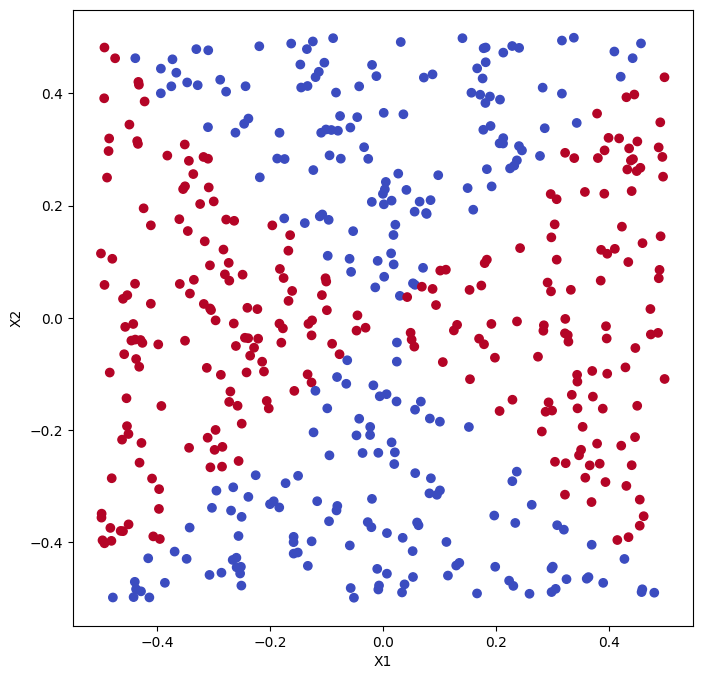

In [175]:
fig, ax = subplots(figsize = (8,8))
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.scatter(x1, x2, c = y, cmap= cm.coolwarm);

(c) Подгоните модель логистической регресси к каддным с использованием перменных $X_{1}$ и $X_{2}$ в качестве предикторов.

In [176]:
X = pd.DataFrame(data = {'X1': x1, 'X2': x2})
X

,X1,X2
0,0.305003,-0.256576
1,0.307941,0.211346
2,0.015326,0.208829
3,-0.214199,-0.078177
4,-0.446069,-0.040580
...,...,...
495,-0.094687,0.289493
496,-0.259470,-0.444608
497,-0.080933,-0.335240
498,0.181635,0.382872


In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [178]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

(d) Примените модель к обучающим данным, чтобы получить предсказания в отношении пренадлежности классу для каждого наблюдения. Выведите наблюдения на график с цветовыми разделеним по предсказанным классам. Решающая граница должна быть линейной 

In [179]:
y_hat_test = log_model.predict(X_test)
confusion_table(y_hat_test, y_test)

Truth,False,True
Predicted,,
False,8,24
True,73,45


In [180]:
print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

       False       0.25      0.10      0.14        81
        True       0.38      0.65      0.48        69

    accuracy                           0.35       150
   macro avg       0.32      0.38      0.31       150
weighted avg       0.31      0.35      0.30       150



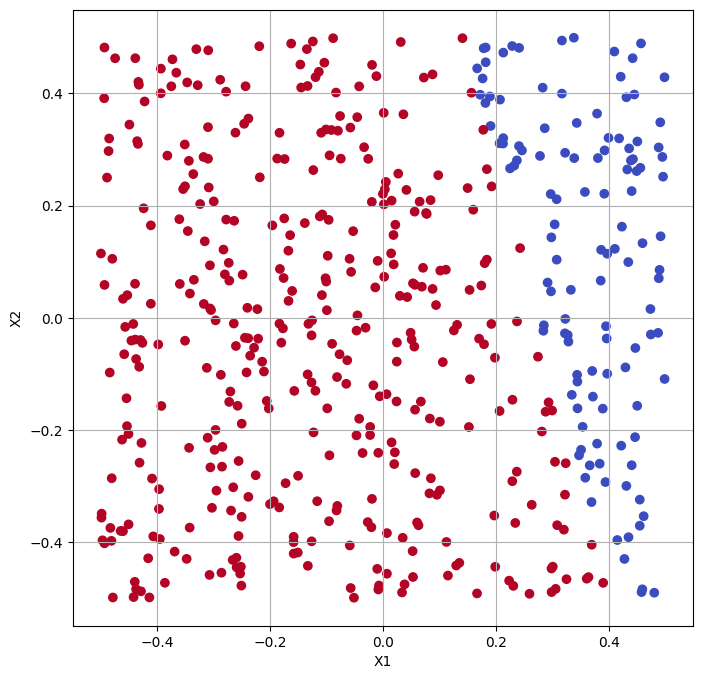

In [181]:
y_hat = log_model.predict(X)

fig, ax = subplots(figsize = (8,8))

sizes = [70 for i in range(len(x1))]

ax.grid()
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.scatter(x1, x2, c = y_hat, cmap= cm.coolwarm);

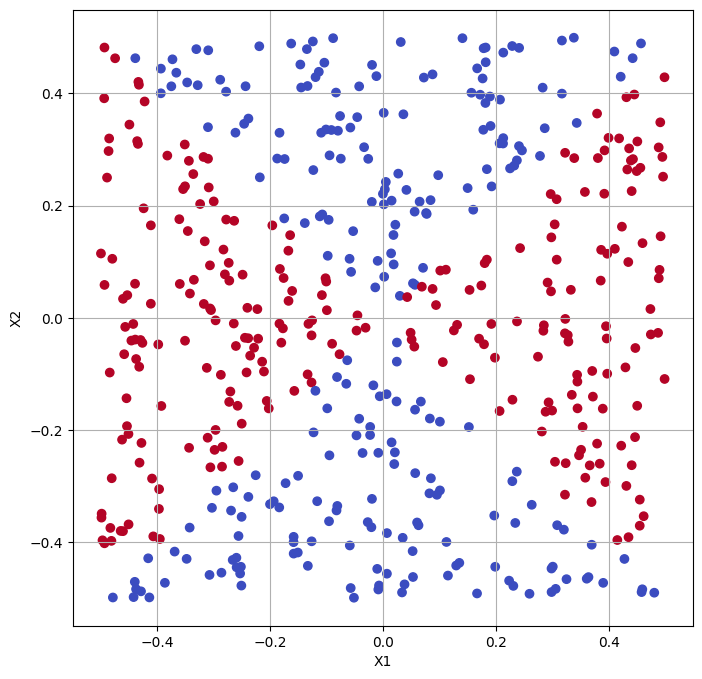

In [182]:
fig, ax = subplots(figsize = (8,8))
ax.grid()
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.scatter(x1, x2, c = y, cmap= cm.coolwarm);

In [183]:
markers = ['^' if i == 1 else 'o' for i in y]

(e) Теперь подгоните модлеь логистической регресси ка данным с использованием нелинейных функций перменных $X_{1}$ и $X_{2}$ в качестве предикторов.

In [184]:
poly = PolynomialFeatures(2)
poly.fit(X)

PolynomialFeatures()

In [185]:
log_model = LogisticRegression()
log_model.fit(poly.transform(X_train), y_train)

LogisticRegression()

In [186]:
y_hat_test = log_model.predict(poly.transform(X_test))

In [187]:
print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

       False       1.00      0.79      0.88        81
        True       0.80      1.00      0.89        69

    accuracy                           0.89       150
   macro avg       0.90      0.90      0.89       150
weighted avg       0.91      0.89      0.89       150



(f) Примените модель к обучающим данным, чтобы получить предсказание в отношении пренадлжености классу для каждого наблюдения. Выведите нблюдения на график с цветовым разделением по предсказаниям.

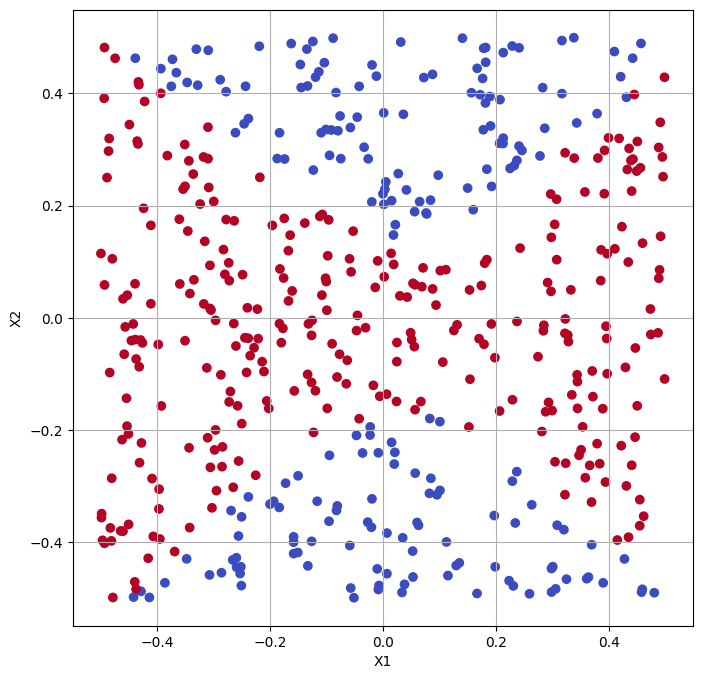

In [188]:
y_hat = log_model.predict(poly.transform(X))
fig, ax = subplots(figsize = (8,8))
ax.grid()
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.scatter(x1, x2, c = y_hat, cmap= cm.coolwarm);

(g) Постройте классификатор на опорнхы векторых по данным с сиспользованием перменнхы $X_{1}$ и $X_{2}$ в качестве предикторов. Получить информацию о предсказанноый принадлжености классу для каждого наблюдения. Выведите наблюдения на график с цветов разделением по предсказанным классам.

In [189]:
svm_linear = SVC(C = 1, kernel = 'linear')

kfold = skm.KFold(5, random_state=0, shuffle = True)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

grid = skm.GridSearchCV(svm_linear, param_grid, refit = True, cv = kfold, scoring = 'accuracy')

In [190]:
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(C=1, kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]},
             scoring='accuracy')

In [191]:
lin_best = grid.best_estimator_

In [192]:
y_hat_test = lin_best.predict(X_test)

print(classification_report(y_test, y_hat_test));

              precision    recall  f1-score   support

       False       0.00      0.00      0.00        81
        True       0.46      1.00      0.63        69

    accuracy                           0.46       150
   macro avg       0.23      0.50      0.32       150
weighted avg       0.21      0.46      0.29       150



C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


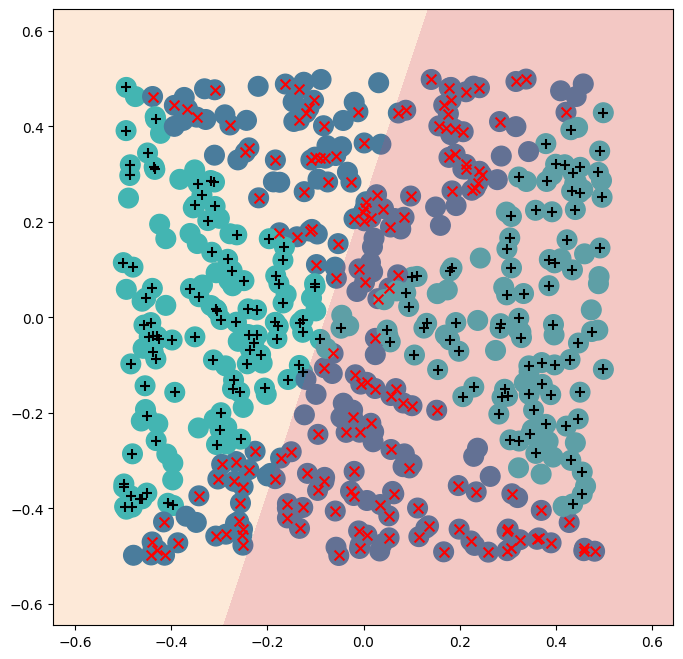

In [193]:
fig, ax = subplots(figsize = (8, 8))

plot_svm(X, y, lin_best, ax = ax);

(h) Постройте модель SVM по этим данным с использованием нелинейного ядра. 

In [194]:
svm_poly = SVC(C = 1, kernel = 'poly', degree = 2)

kfold = skm.KFold(5, random_state=0, shuffle = True)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100], 'degree': [2, 3, 4, 5, 6]}

grid = skm.GridSearchCV(svm_poly, param_grid, refit = True, cv = kfold, scoring = 'accuracy')

In [195]:
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(C=1, degree=2, kernel='poly'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100],
                         'degree': [2, 3, 4, 5, 6]},
             scoring='accuracy')

In [196]:
poly_best = grid.best_estimator_

In [197]:
y_hat_test = poly_best.predict(X_test)

print(classification_report(y_test, y_hat_test));

              precision    recall  f1-score   support

       False       1.00      0.99      0.99        81
        True       0.99      1.00      0.99        69

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


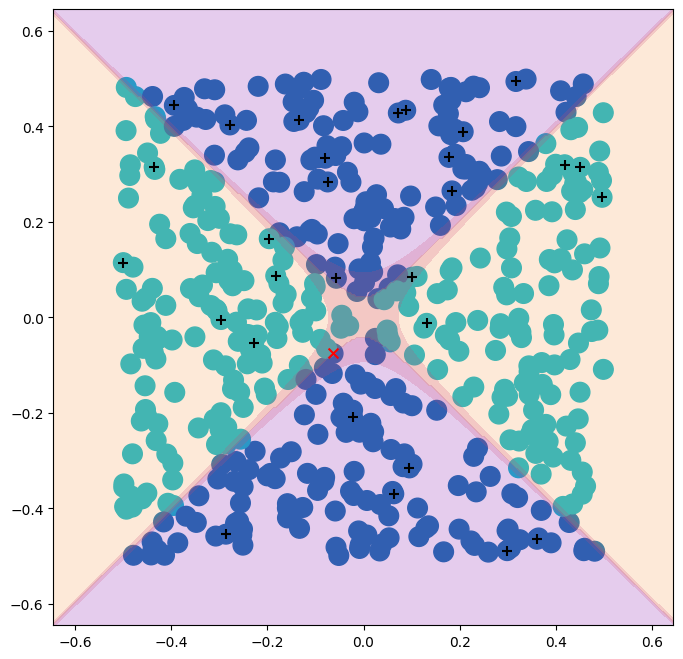

In [198]:
fig, ax = subplots(figsize = (8, 8))

plot_svm(X, y, poly_best, ax = ax);

(i) По полученным результам видном, что хуже всего, как и ожидалось себя показали проста логистическая регрессия и классификатор на опорных векторах. Полиномиальная логистическая регрессия показала себя чуть хуже, SVM с полиномиальным ядром.

### Задание 6.

В конце раздела 9.6.1 было заявлено, что в случае с данными, которые трудно, но возможно разделить линейно, классификатор на опорнхы векторах с небольшим значениями парметра C, позволяющий неправильное отнесение обучающих наблюдений к классу, может показывать лучший результат на контрольных данных в сравнении с использованием классификатора с огомным занчениями парметра C, не допускающего неправильных отнесений обучающих наблюдений к классам. Давайте исследуем это уотверждение.

(a) Сгенерируйте набор данных, состоящих из p = 2 предикторов с двумя классами, которые едва разделимы линенйо границей.

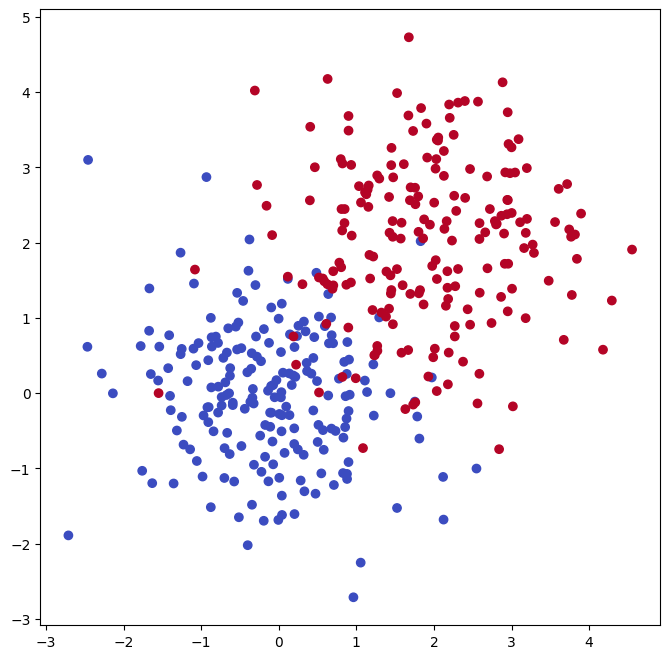

In [199]:
rng = np.random.default_rng(1)
x = rng.standard_normal((400, 2))
y = np.array([-1]*200 + [1]*200)
x[y==1] += 2
fig, ax = subplots(figsize = (8,8))
ax.scatter(x[:, 0], x[:, 1], c = y, cmap = cm.coolwarm);

(b) Рассчитайте частоту ошибк кросс-валидации для классификатора на опорнхы векторхы для разных значений парметра c. Какое количество обучающих наблюдений было неправильно отнесено к классам для каждого значения C, и как это количество соотносится с полученными ошибками перекрестной проверки?

In [200]:
X = pd.DataFrame(data = {'X1': x[:, 0], 'X2': x[:, 1]})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [201]:
svc_linear = SVC(C = 1.0, kernel = 'linear')

kfold = skm.KFold(n_splits = 5, random_state = 42, shuffle = True)

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid = skm.GridSearchCV(estimator = svc_linear, refit = True ,param_grid = param_grid, cv = kfold, scoring = 'accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='accuracy')

''

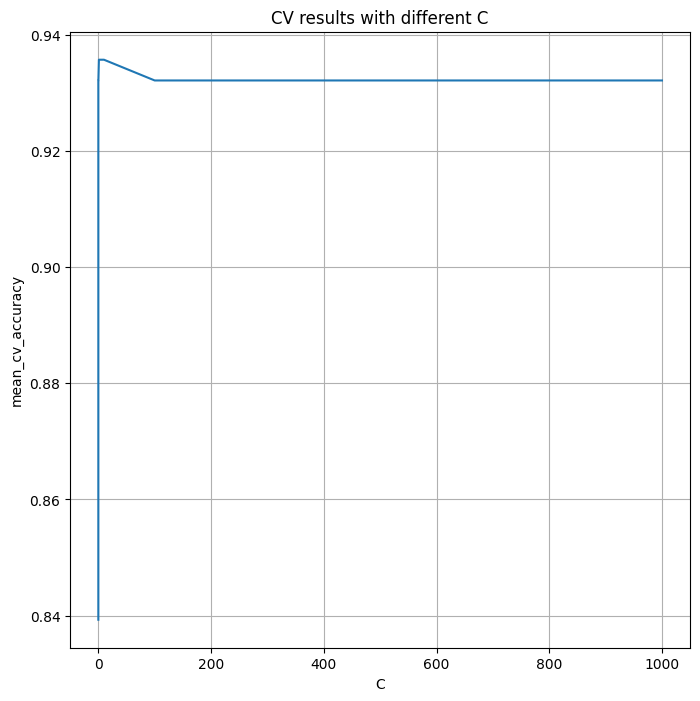

In [202]:
fig, ax = subplots(figsize = (8, 8))

ax.plot(grid.cv_results_['param_C'], grid.cv_results_['mean_test_score'])
ax.set_xlabel('C')
ax.set_ylabel('mean_cv_accuracy')
ax.set_title('CV results with different C')
ax.grid()
;

### Задание 7.

В данном упражнении мы постараемс с омощьюя мтеодв, основанных на опорных векторах, предсказать, много или мало топлива расходует машина. Для этого воспользуемся набором даннхы Auto.

(a) Создайте бинарную перменную, которая принимает значение 1 в случае, если расход топлива (после mpg) превышает медианное значение по колонке, и 0 - 1 в противном случае.

In [203]:
auto = load_data('Auto')

In [204]:
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [205]:
len(auto)

392

In [206]:
X = auto.drop(columns = 'mpg', axis = 1)
y = pd.DataFrame(data = {'high_mpg': auto['mpg'] > auto['mpg'].median()})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

(b) Постройте классификатор на опорных векторах для разных значенй C с целью предскзать, будет ли миша расходвать много или мало бензина. Сообщите об ошибке кросс-валидации для рахных значений перменной C. Прокомментируйте результаты.

In [207]:
svc_linear = SVC(C = 1.0, kernel = 'linear')

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
kfold = skm.KFold(n_splits = 5, shuffle = True, random_state = 42)

grid = skm.GridSearchCV(estimator = svc_linear, param_grid = param_grid, cv = kfold, scoring = 'accuracy', refit = True)
grid.fit(X_train, y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConve

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

''

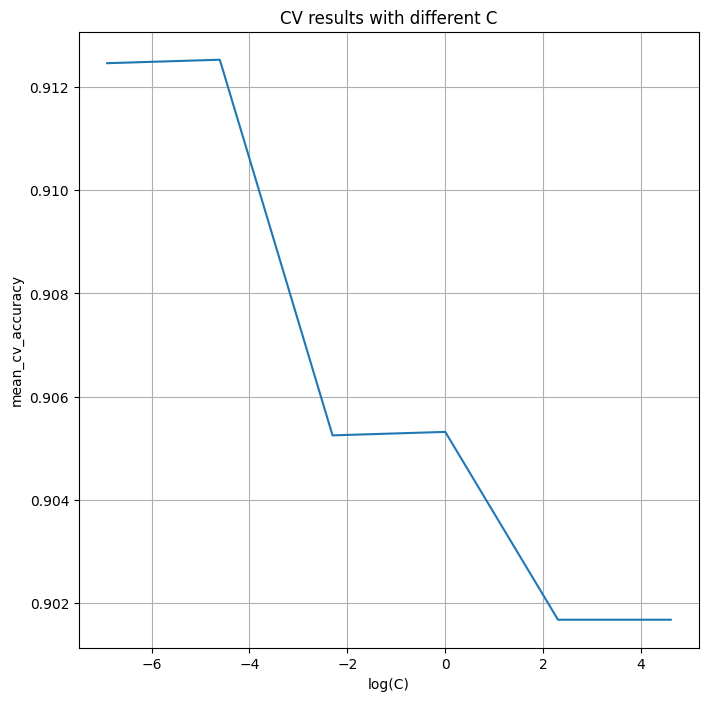

In [208]:
fig, ax = subplots(figsize = (8, 8))

ax.plot(np.log(grid.cv_results_['param_C']), grid.cv_results_['mean_test_score'])
ax.set_xlabel('log(C)')
ax.set_ylabel('mean_cv_accuracy')
ax.set_title('CV results with different C')
ax.grid()
;

In [209]:
best_lin = grid.best_estimator_
grid.best_params_

{'C': 0.01}

In [210]:
y_hat_test= best_lin.predict(X_test)

print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

       False       1.00      0.80      0.89        65
        True       0.80      1.00      0.89        53

    accuracy                           0.89       118
   macro avg       0.90      0.90      0.89       118
weighted avg       0.91      0.89      0.89       118



In [211]:
confusion_table(y_hat_test, y_test)

Truth,False,True
Predicted,,
False,52,0
True,13,53


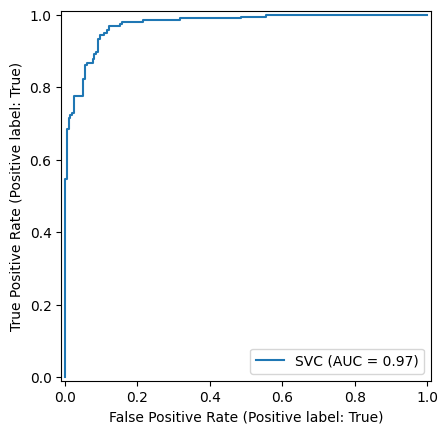

In [212]:
roc_curve(best_lin, X, y);

(c) Поторите пункт (b) - на этот раз воспользовавшись классификатором SVM с радиальным или полиномиальным ядром для разных значений парметров gamma и deree, а также C.

In [213]:
svc_rbf = SVC(kernel = 'rbf')

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
kfold = skm.KFold(n_splits = 5, shuffle = True, random_state = 42)

grid = skm.GridSearchCV(estimator = svc_rbf , param_grid = param_grid, cv = kfold, scoring = 'accuracy', refit = True)
grid.fit(X_train, y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConve

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [214]:
best_rbf = grid.best_estimator_
grid.best_params_

{'C': 1, 'gamma': 0.001}

In [215]:
y_hat_test= best_rbf.predict(X_test)

print(classification_report(y_test, y_hat_test))

              precision    recall  f1-score   support

       False       0.98      0.83      0.90        65
        True       0.83      0.98      0.90        53

    accuracy                           0.90       118
   macro avg       0.90      0.91      0.90       118
weighted avg       0.91      0.90      0.90       118



In [216]:
confusion_table(y_hat_test, y_test)

Truth,False,True
Predicted,,
False,54,1
True,11,52


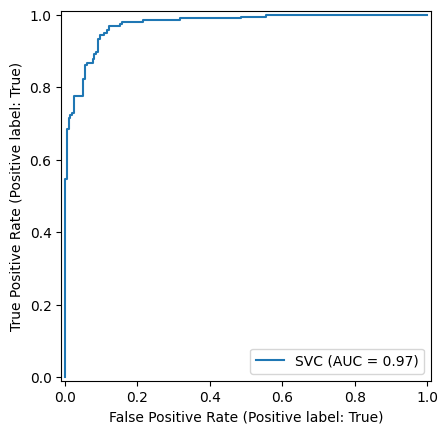

In [217]:
roc_curve(best_lin, X, y);

Видно, что SVM с rbf показала себя немного лучше SVC с линейным ядром.